In [2]:
from google.colab import files

uploaded = files.upload()

Saving demand_forecasting_data.csv to demand_forecasting_data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("demand_forecasting_data.csv")

df.head()

,Date,Product_ID,Base_Sales,Marketing_Campaign,Marketing_Effect,Seasonal_Trend,Seasonal_Effect,Price,Discount,Competitor_Price,Stock_Availability,Public_Holiday,Demand
0,2019-01-01,P002,65,Social Media,1.634270,Spring,1.0,73.496059,0.078198,64.173418,491,False,60570
1,2019-01-01,P004,94,Social Media,1.240566,Summer,1.2,74.271862,0.182151,69.571391,135,True,18143
2,2019-01-01,P003,125,Radio,1.087600,Summer,1.2,35.274616,0.102592,27.331268,180,False,37412
3,2019-01-01,P004,128,TV,1.831657,Winter,0.8,79.524248,0.196125,73.429502,227,False,40773
4,2019-01-01,P001,51,Radio,1.285161,Fall,1.1,96.237402,0.079253,88.243871,338,False,26917


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
for column in df.columns:
    print(column)

Dataset Shape: (35000, 13)

Column Names:
Date
Product_ID
Base_Sales
Marketing_Campaign
Marketing_Effect
Seasonal_Trend
Seasonal_Effect
Price
Discount
Competitor_Price
Stock_Availability
Public_Holiday
Demand


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                35000 non-null  object 
 1   Product_ID          35000 non-null  object 
 2   Base_Sales          35000 non-null  int64  
 3   Marketing_Campaign  27933 non-null  object 
 4   Marketing_Effect    35000 non-null  float64
 5   Seasonal_Trend      35000 non-null  object 
 6   Seasonal_Effect     35000 non-null  float64
 7   Price               35000 non-null  float64
 8   Discount            35000 non-null  float64
 9   Competitor_Price    35000 non-null  float64
 10  Stock_Availability  35000 non-null  int64  
 11  Public_Holiday      35000 non-null  bool   
 12  Demand              35000 non-null  int64  
dtypes: bool(1), float64(5), int64(3), object(4)
memory usage: 3.2+ MB


In [6]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Date                     0
Product_ID               0
Base_Sales               0
Marketing_Campaign    7067
Marketing_Effect         0
Seasonal_Trend           0
Seasonal_Effect          0
Price                    0
Discount                 0
Competitor_Price         0
Stock_Availability       0
Public_Holiday           0
Demand                   0
dtype: int64


In [7]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)


Missing Value Percentage:
Date                   0.000000
Product_ID             0.000000
Base_Sales             0.000000
Marketing_Campaign    20.191429
Marketing_Effect       0.000000
Seasonal_Trend         0.000000
Seasonal_Effect        0.000000
Price                  0.000000
Discount               0.000000
Competitor_Price       0.000000
Stock_Availability     0.000000
Public_Holiday         0.000000
Demand                 0.000000
dtype: float64


In [8]:
print(df["Marketing_Campaign"].value_counts(dropna=False))

Marketing_Campaign
NaN             7067
Radio           7049
TV              7040
Email           7027
Social Media    6817
Name: count, dtype: int64


In [9]:
print(df["Marketing_Campaign"].unique())

['Social Media' 'Radio' 'TV' nan 'Email']


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
df["Marketing_Campaign"] = df["Marketing_Campaign"].fillna("No Campaign")

In [12]:
print(df.isnull().sum())

Date                  0
Product_ID            0
Base_Sales            0
Marketing_Campaign    0
Marketing_Effect      0
Seasonal_Trend        0
Seasonal_Effect       0
Price                 0
Discount              0
Competitor_Price      0
Stock_Availability    0
Public_Holiday        0
Demand                0
dtype: int64


In [13]:
print(df["Marketing_Campaign"].value_counts())

Marketing_Campaign
No Campaign     7067
Radio           7049
TV              7040
Email           7027
Social Media    6817
Name: count, dtype: int64


In [14]:
df.describe()

,Base_Sales,Marketing_Effect,Seasonal_Effect,Price,Discount,Competitor_Price,Stock_Availability,Demand
count,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000
mean,124.310857,1.399607,1.023937,64.978204,0.124819,59.474173,254.027686,48237.904000
std,43.370933,0.377013,0.148251,20.129806,0.043347,20.322941,141.721795,37809.256224
min,50.000000,0.960101,0.800000,30.002821,0.050000,20.018921,10.000000,505.000000
25%,87.000000,1.057890,0.800000,47.591650,0.087568,42.157852,131.000000,19637.500000
50%,124.000000,1.320028,1.000000,65.083525,0.124566,59.569889,254.000000,39112.500000
75%,162.000000,1.628659,1.100000,82.392712,0.162095,76.859092,377.000000,67367.000000
max,199.000000,2.399656,1.200000,99.997372,0.199998,98.902377,499.000000,285337.000000


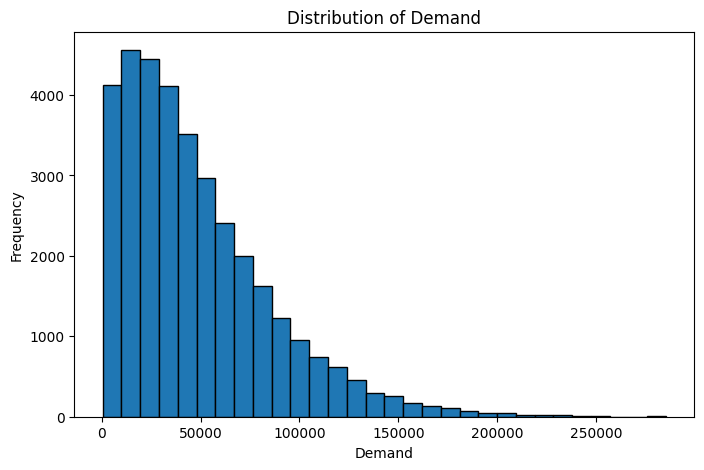

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(df["Demand"], bins=30, edgecolor="black")

plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.title("Distribution of Demand")

plt.show()

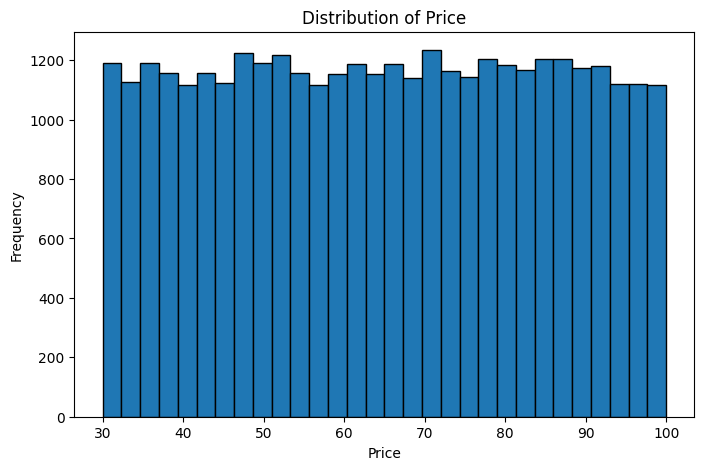

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=30, edgecolor="black")

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Price")

plt.show()

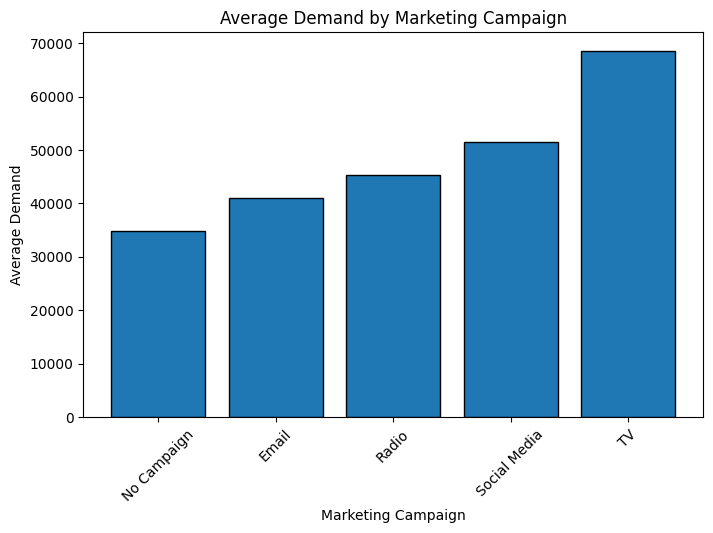

In [17]:
campaign_demand = df.groupby("Marketing_Campaign")["Demand"].mean().sort_values()

plt.figure(figsize=(8, 5))

plt.bar(campaign_demand.index, campaign_demand.values, edgecolor="black")

plt.xlabel("Marketing Campaign")
plt.ylabel("Average Demand")
plt.title("Average Demand by Marketing Campaign")

plt.xticks(rotation=45)

plt.show()

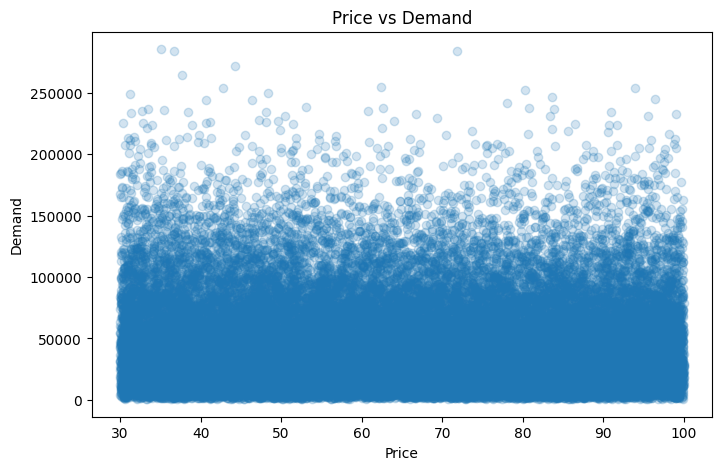

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Price"], df["Demand"], alpha=0.2)

plt.xlabel("Price")
plt.ylabel("Demand")
plt.title("Price vs Demand")

plt.show()

In [19]:
print("Correlation between Price and Demand:")
print(df["Price"].corr(df["Demand"]))

Correlation between Price and Demand:
-0.044080855546115044


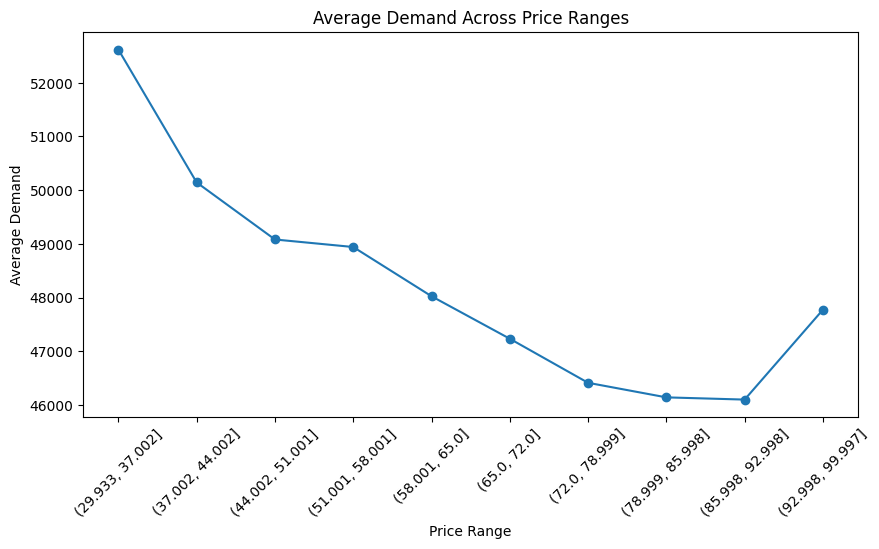

In [20]:
df["Price_Bin"] = pd.cut(df["Price"], bins=10)

price_demand = df.groupby("Price_Bin", observed=False)["Demand"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    [str(x) for x in price_demand.index],
    price_demand.values,
    marker="o"
)

plt.xlabel("Price Range")
plt.ylabel("Average Demand")
plt.title("Average Demand Across Price Ranges")

plt.xticks(rotation=45)
plt.show()

In [21]:
print("Correlation between Competitor Price and Demand:")
print(df["Competitor_Price"].corr(df["Demand"]))

Correlation between Competitor Price and Demand:
-0.05243542189335214


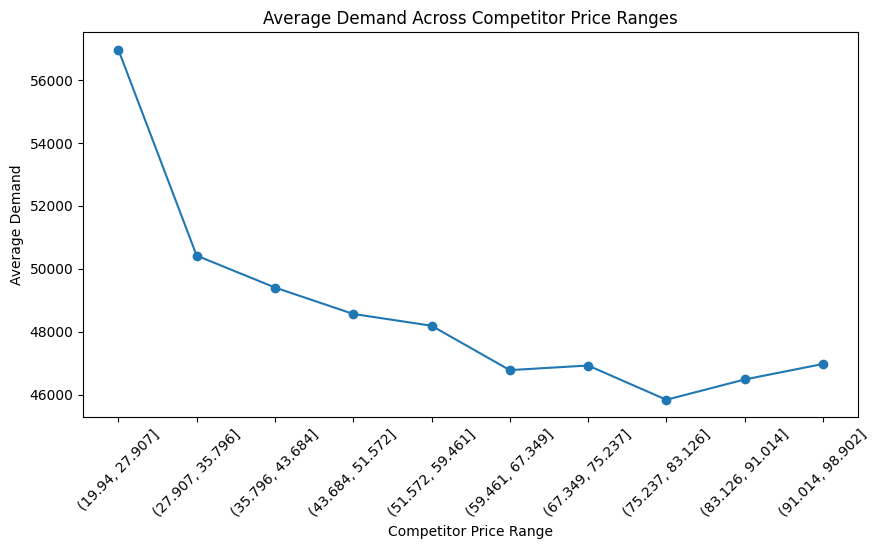

In [22]:
df["Competitor_Price_Bin"] = pd.cut(df["Competitor_Price"], bins=10)

competitor_demand = df.groupby(
    "Competitor_Price_Bin",
    observed=False
)["Demand"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    [str(x) for x in competitor_demand.index],
    competitor_demand.values,
    marker="o"
)

plt.xlabel("Competitor Price Range")
plt.ylabel("Average Demand")
plt.title("Average Demand Across Competitor Price Ranges")

plt.xticks(rotation=45)
plt.show()

In [23]:
print("Correlation between Discount and Demand:")
print(df["Discount"].corr(df["Demand"]))

Correlation between Discount and Demand:
-0.05642106531131057


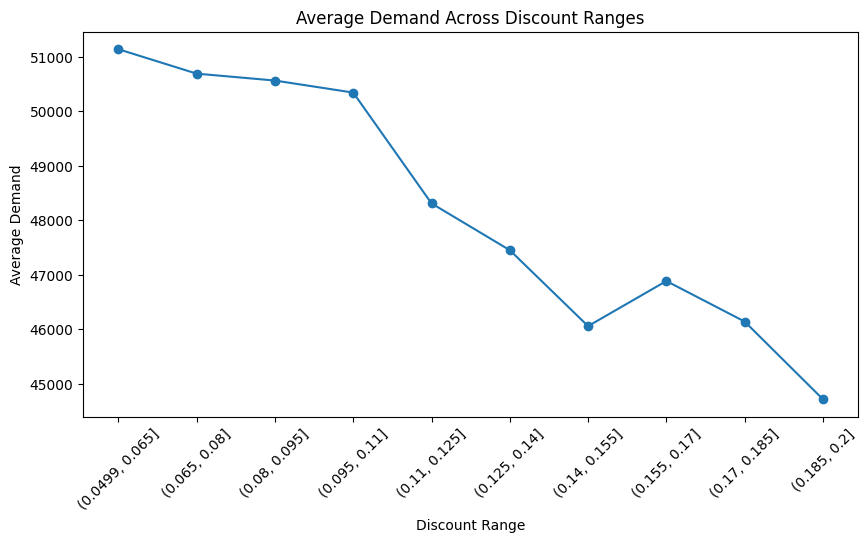

In [24]:
df["Discount_Bin"] = pd.cut(df["Discount"], bins=10)

discount_demand = df.groupby(
    "Discount_Bin",
    observed=False
)["Demand"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    [str(x) for x in discount_demand.index],
    discount_demand.values,
    marker="o"
)

plt.xlabel("Discount Range")
plt.ylabel("Average Demand")
plt.title("Average Demand Across Discount Ranges")

plt.xticks(rotation=45)
plt.show()

In [25]:
print("Correlation between Stock Availability and Demand:")
print(df["Stock_Availability"].corr(df["Demand"]))

Correlation between Stock Availability and Demand:
0.7094201778418942


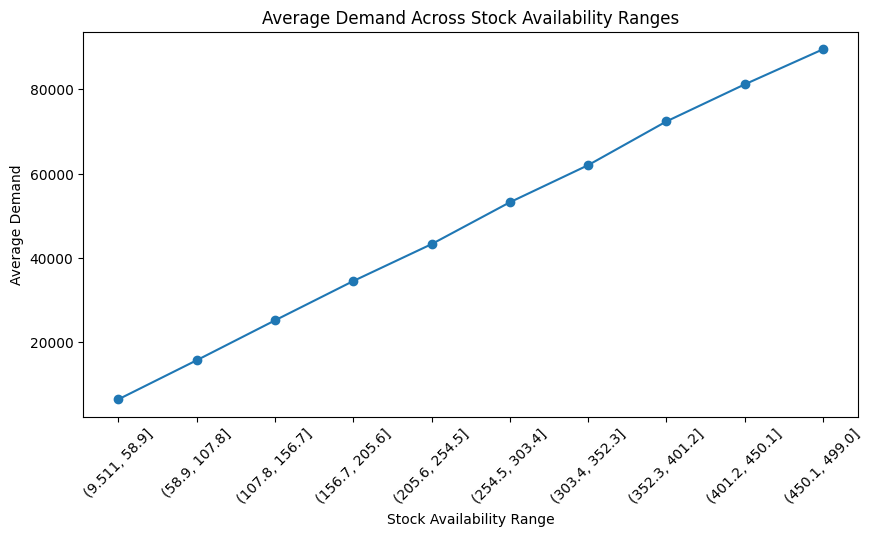

In [26]:
df["Stock_Bin"] = pd.cut(df["Stock_Availability"], bins=10)

stock_demand = df.groupby(
    "Stock_Bin",
    observed=False
)["Demand"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    [str(x) for x in stock_demand.index],
    stock_demand.values,
    marker="o"
)

plt.xlabel("Stock Availability Range")
plt.ylabel("Average Demand")
plt.title("Average Demand Across Stock Availability Ranges")

plt.xticks(rotation=45)
plt.show()

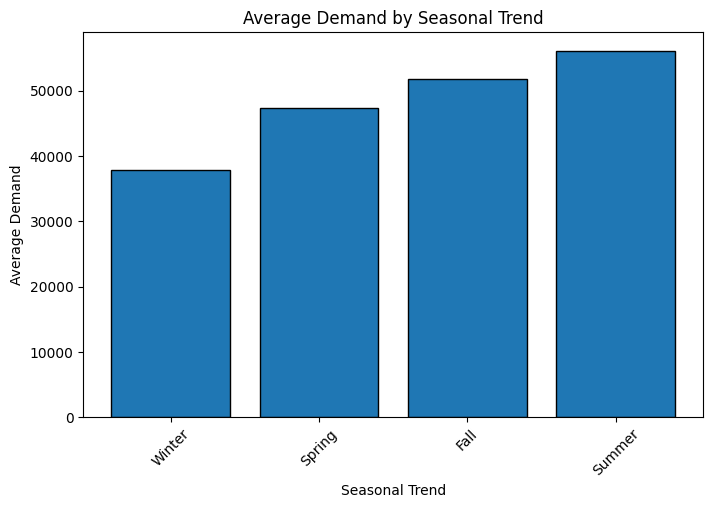

In [27]:
seasonal_demand = df.groupby("Seasonal_Trend")["Demand"].mean().sort_values()

plt.figure(figsize=(8, 5))

plt.bar(
    seasonal_demand.index,
    seasonal_demand.values,
    edgecolor="black"
)

plt.xlabel("Seasonal Trend")
plt.ylabel("Average Demand")
plt.title("Average Demand by Seasonal Trend")

plt.xticks(rotation=45)
plt.show()

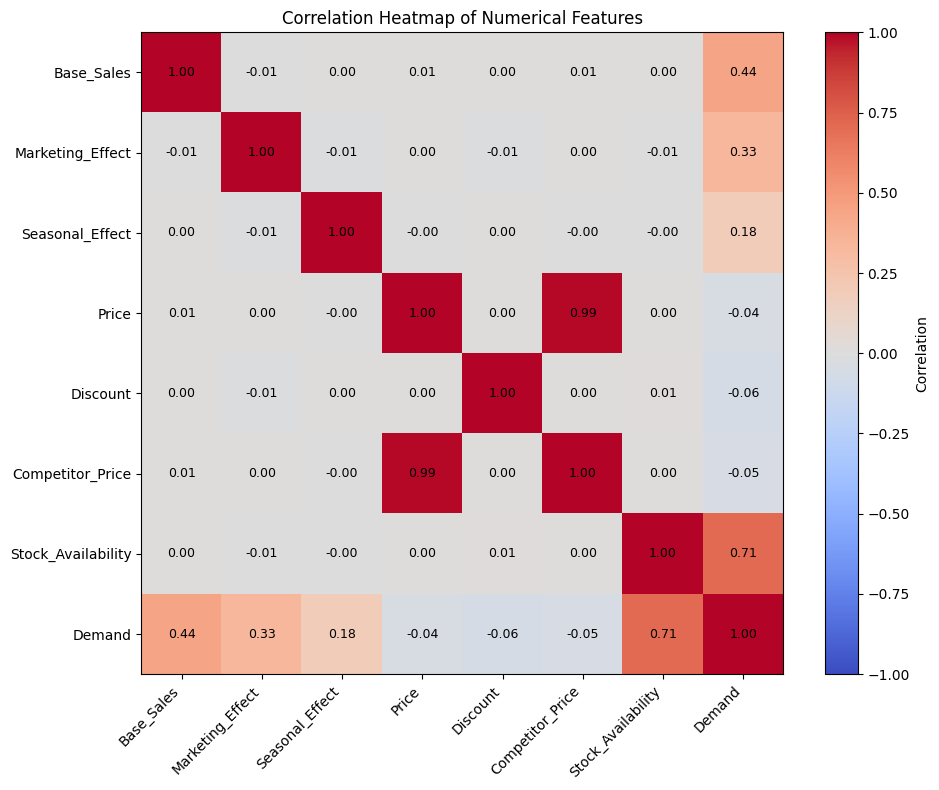

In [29]:
import matplotlib.pyplot as plt

numerical_columns = [
    "Base_Sales",
    "Marketing_Effect",
    "Seasonal_Effect",
    "Price",
    "Discount",
    "Competitor_Price",
    "Stock_Availability",
    "Demand"
]

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))

heatmap = plt.imshow(
    correlation_matrix,
    interpolation="nearest",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.colorbar(heatmap, label="Correlation")

plt.xticks(
    range(len(numerical_columns)),
    numerical_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numerical_columns)),
    numerical_columns
)

# Add correlation values inside each cell
for i in range(len(numerical_columns)):
    for j in range(len(numerical_columns)):
        value = correlation_matrix.iloc[i, j]
        plt.text(
            j, i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()